# 1. Exploration et ingestion

In [44]:
import os
import locale
import json
from io import BytesIO

import kagglehub
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from azure.storage.blob import BlobServiceClient

locale.setlocale(locale.LC_ALL, 'fr_FR.UTF-8')

'fr_FR.UTF-8'

**Prérequis :**
1. Ajouter votre identifiant et votre clé API Kaggle à votre `.env`

2. Ajouter à votre `.env` les informations nécessaire pour la connexion à votre Azure Blob Storage (cf la section 1.7 pour les prérequis spécifiques à Azure)

In [45]:
from dotenv import load_dotenv

# Charge les variables (identifiants Kaggle) depuis le fichier .env
load_dotenv()

True

In [46]:
OUT_DIR = 'data'
LOCAL_FILE = 'blackfriday_clean.csv'
BLOB_NAME = LOCAL_FILE

os.makedirs(OUT_DIR, exist_ok=True)

## 1.1 Chargement des données

https://www.kaggle.com/datasets/sdolezel/black-friday

In [47]:
file_name = "train.csv"

In [48]:
# téléchargement du dataset
path = kagglehub.dataset_download("sdolezel/black-friday")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\p02114\.cache\kagglehub\datasets\sdolezel\black-friday\versions\1


In [49]:
dataset_path = Path(path) / file_name

if dataset_path.exists():
    df = pd.read_csv(dataset_path)
    print("Dataset chargé avec succès.")
else:
    raise FileNotFoundError(f"""Le chemin spécifié est invalide: '{dataset_path.as_posix()}'.
        Vérifiez si le fichier a été téléchargé avec succès.""")

Dataset chargé avec succès.


In [50]:
# Dimensions du dataset
print(f"Nombre de lignes : {df.shape[0]:n}")
print(f"Nombre de colonnes : {df.shape[1]:n}")

Nombre de lignes : 550 068
Nombre de colonnes : 12


In [51]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


## 1.2 EDA

__Features :__
- `User_ID` : ID utilisateur
- `Product_ID` : ID produit
- `Gender` : sexe de l'utilisateur
- `Age` : tranches d'âges
- `Occupation` : occupation de l'utilisateur (anonymisé)
- `City_Category` : catégorie de la ville (A, B, C - ordinal ?)
- `Stay_In_Current_City_Years` : nombre d'années passées dans la ville actuelle
- `Marital_Status` : statut marital (marié 1 ou non 0)
- `Product_Category_1` : catégorie principale du produit (anonymisé)
- `Product_Category_2` : 2ème catégorie du produit (anonymisé)
- `Product_Category_3` : 3ème catégorie du produit (anonymisé)
- `Purchase` : quantité achetée

*NB : un produit peut avoir plusieurs catégories*

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


En réalité, hormis `Purchase` la plupart des variables numériques sont en réalité des varaibles catégorielles encodées (`Occupation`, `Marital_Status`, `Product_Category_X`). De plus, les variables `Product_Category_2` et `Product_Category_3` sont sans doute des `float`à cause des valeurs manquantes.

Enfin, nous avons des types `str` pour les variables que nous aurions, à priori, classés en tant que numériques `Age` et `Stay_In_Current_City_Years` car :
1. `Age` est un regroupement par tranches d'âges
2. les gens qui sont restés 4 ans et plus dans une ville sont regroupés dans `Stay_In_Current_City_Years`

In [53]:
df.Age.value_counts().sort_index()

Age
0-17      15102
18-25     99660
26-35    219587
36-45    110013
46-50     45701
51-55     38501
55+       21504
Name: count, dtype: int64

In [54]:
df.Stay_In_Current_City_Years.value_counts().sort_index()

Stay_In_Current_City_Years
0      74398
1     193821
2     101838
3      95285
4+     84726
Name: count, dtype: int64

In [55]:
# nombre de valeurs uniques par variables
df.nunique()

User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category_1               20
Product_Category_2               17
Product_Category_3               15
Purchase                      18105
dtype: int64

## 1.3 Gestion des valeurs manquantes

In [56]:
count_na = df.isnull().sum()

count_na[count_na != 0] / df.shape[0]

Product_Category_2    0.315666
Product_Category_3    0.696727
dtype: float64

Les valeurs manquantes se concentrent sur les catégories supplémentaires pour les produits qui doivent être optionnelles.
On a 32% de valeurs manquantes pour `Product_Category_2` et 70% pour `Product_Category_3`.

In [57]:
df['Product_Category_1'].value_counts().sort_index()

Product_Category_1
1     140378
2      23864
3      20213
4      11753
5     150933
6      20466
7       3721
8     113925
9        410
10      5125
11     24287
12      3947
13      5549
14      1523
15      6290
16      9828
17       578
18      3125
19      1603
20      2550
Name: count, dtype: int64

Comme les catégories sont encodées entre 1 et 20. On peut remplacer les valeurs manquantes par `0` ou `-1`.

In [58]:
df = df.fillna(0)

In [59]:
df[
    ['Product_Category_2', 'Product_Category_3']
] = df[['Product_Category_2', 'Product_Category_3']].astype(int)

## 1.4 DataViz rapide

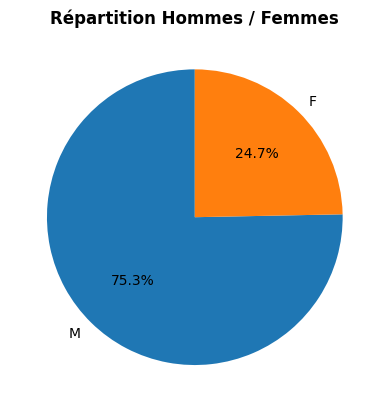

In [60]:
# Répartition des sexes
df["Gender"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90, 
)
plt.title("Répartition Hommes / Femmes", fontweight="bold")
plt.ylabel("");

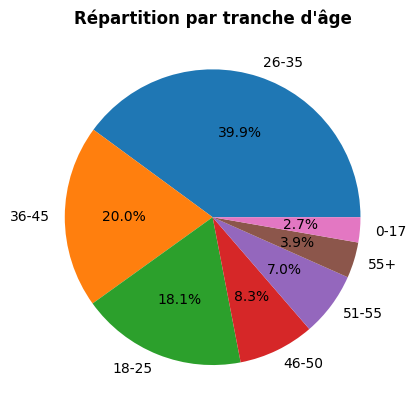

In [61]:
# Répartition par tranche d'âge
df["Age"].value_counts().plot.pie(
    autopct="%1.1f%%",
    #startangle=90, 
)
plt.title("Répartition par tranche d'âge", fontweight="bold")
plt.ylabel("");

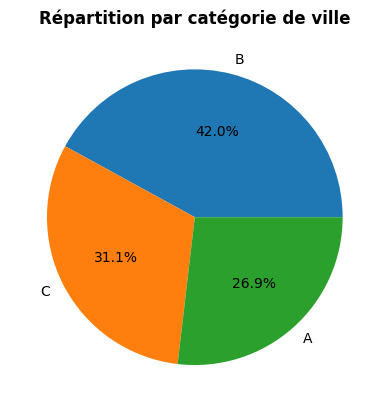

In [62]:
# Répartition par catégorie de ville
df["City_Category"].value_counts().plot.pie(
    autopct="%1.1f%%",
    #startangle=90, 
)
plt.title("Répartition par catégorie de ville", fontweight="bold")
plt.ylabel("");

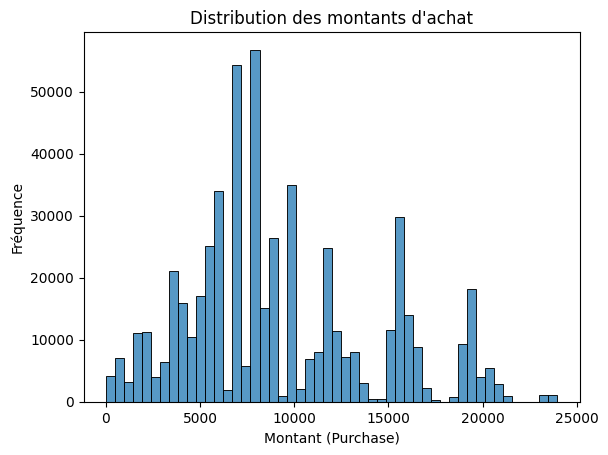

In [63]:
# Histogramme des montants d’achat
sns.histplot(data=df, x="Purchase", bins=50)
plt.title("Distribution des montants d'achat")
plt.xlabel("Montant (Purchase)")
plt.ylabel("Fréquence");

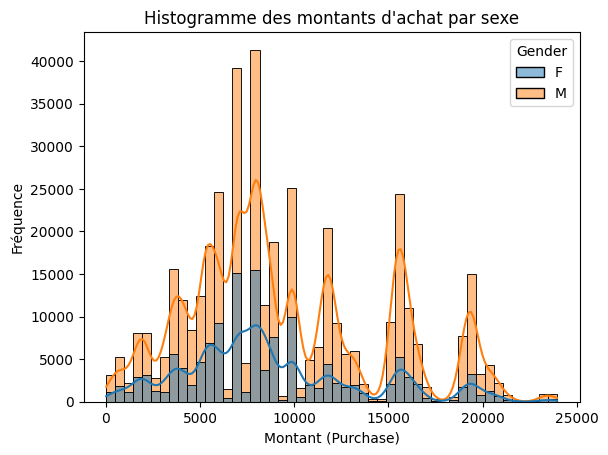

In [64]:
# Histogramme des montants d’achat par sexe
sns.histplot(data=df, x="Purchase", hue="Gender", bins=50, kde=True)
plt.title("Histogramme des montants d'achat par sexe")
plt.xlabel("Montant (Purchase)")
plt.ylabel("Fréquence");

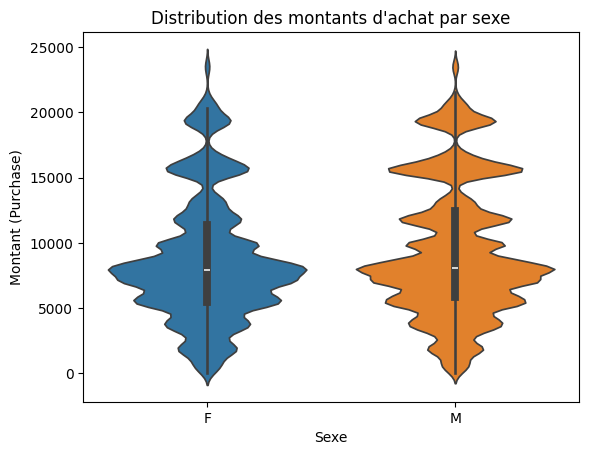

In [65]:
sns.violinplot(data=df, x="Gender", y="Purchase", hue="Gender")
plt.title("Distribution des montants d'achat par sexe")
plt.xlabel("Sexe")
plt.ylabel("Montant (Purchase)");

Plus d'achats > 10_000 pour les hommes.

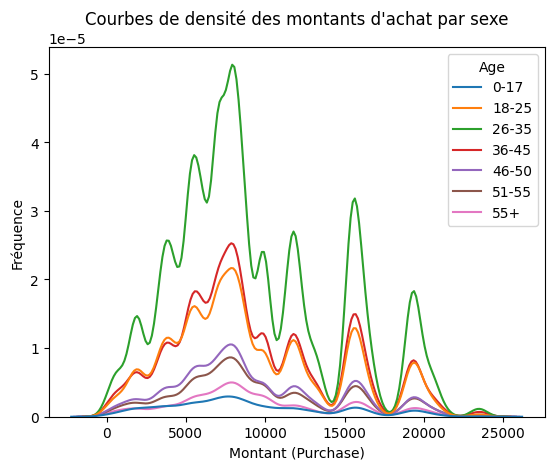

In [66]:
# Courbes de densité des montants d’achat par tranche d'âge 
sns.kdeplot(data=df, x="Purchase", hue="Age", hue_order=sorted(df.Age.unique()))
plt.title("Courbes de densité des montants d'achat par sexe")
# somme de toutes les aires sous les courbes = 1
plt.xlabel("Montant (Purchase)")
plt.ylabel("Fréquence");

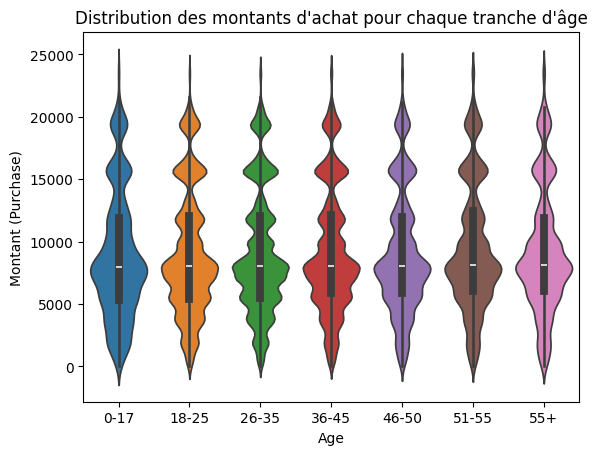

In [67]:
sns.violinplot(data=df.sort_values(by="Age"), x="Age", y="Purchase", hue="Age")
plt.title("Distribution des montants d'achat pour chaque tranche d'âge")
plt.ylabel("Montant (Purchase)");

Comme attendu, moins d'achats pour les 0-17 et pour des montants plus faibles. Plus d'achats pour les 26-35 (en général, début de vie de famille avec premiers enfants et situation salariale plus stable) et, en proportion, plus d'achats pour des montants > 10_000.

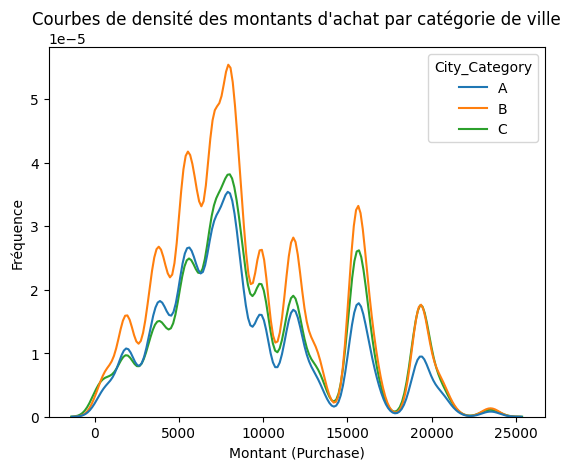

In [68]:
# Courbes de densité des montants d’achat par catégorie de ville 
sns.kdeplot(data=df, x="Purchase", hue="City_Category", hue_order=sorted(df.City_Category.unique()))
plt.title("Courbes de densité des montants d'achat par catégorie de ville")
# somme de toutes les aires sous les courbes = 1
plt.xlabel("Montant (Purchase)")
plt.ylabel("Fréquence");

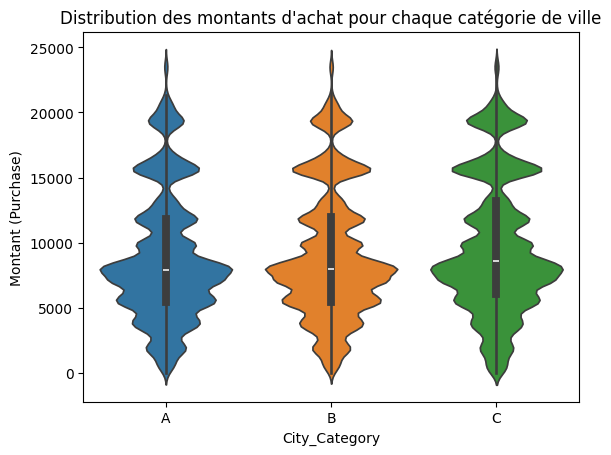

In [69]:
sns.violinplot(
    data=df.sort_values(by="City_Category"), 
    x="City_Category", 
    y="Purchase", 
    hue="City_Category"
    )
plt.title("Distribution des montants d'achat pour chaque catégorie de ville")
plt.ylabel("Montant (Purchase)");

Proportionnellement, plus de gros montants pour les catégories B p/r à C et A.

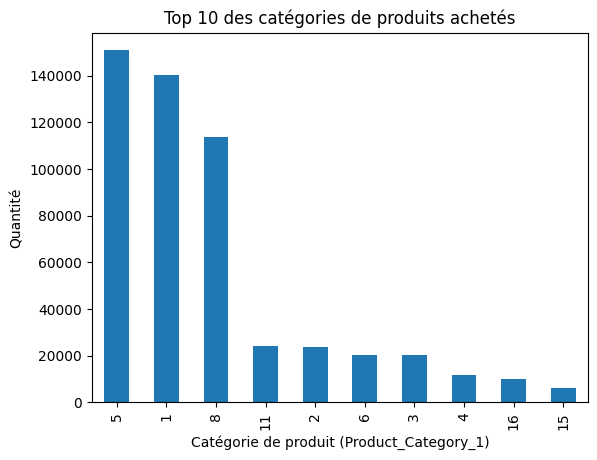

In [70]:
# top 10 des catégories de produits achetés
df.groupby('Product_Category_1')['Purchase']\
  .count()\
  .sort_values(ascending=False)\
  .head(10)\
  .plot.bar()
plt.title("Top 10 des catégories de produits achetés")
plt.xlabel("Catégorie de produit (Product_Category_1)")
plt.ylabel("Quantité");

Les catégories de produit les plus achetées sont les catégories 5, 1 et 8.

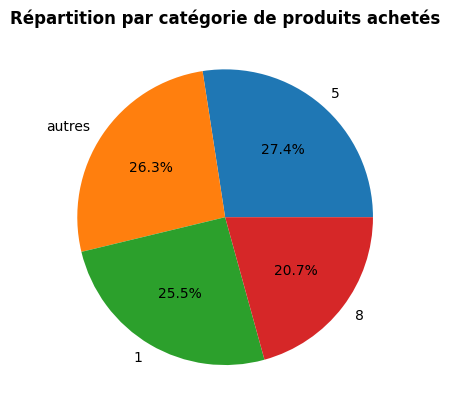

In [71]:
# Répartition par catégorie de ville
df["Product_Category_1"].map(lambda x: x if x in {1, 5, 8} else "autres")\
                        .value_counts()\
                        .plot.pie(
    autopct="%1.1f%%",
    #startangle=90, 
)
plt.title("Répartition par catégorie de produits achetés", fontweight="bold")
plt.ylabel("");

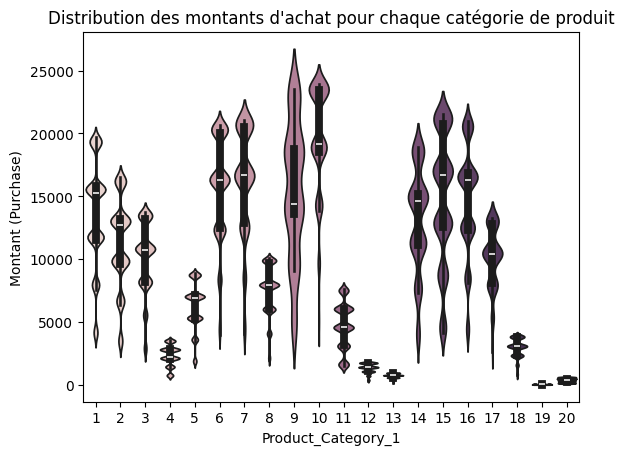

In [72]:
sns.violinplot(
    data=df.sort_values(by="Product_Category_1"), 
    x="Product_Category_1", 
    y="Purchase", 
    hue="Product_Category_1",
    legend=False
    )
plt.title("Distribution des montants d'achat pour chaque catégorie de produit")
plt.ylabel("Montant (Purchase)");

Les produits 9, 10, 16, 7 et 6 sont les produits avec les montants les plus élevés.

## 1.5 Encodage des valeurs

Comme suggéré dans l'énoncé, nous allons encoder les variables catégorielles restantes.

In [73]:
# colonnes à encoder
cat_cols = [col for col in df.select_dtypes(exclude='number').columns if col != 'Product_ID']

In [74]:
# dictionnaire pour l'encoding
dict_encoding = {}
dict_decoding = {}

for col in cat_cols:
    values = sorted(df[col].unique())
    dict_encoding[col] = {v: i for i, v in enumerate(values)}
    dict_decoding[col] = {i: v for i, v in enumerate(values)}

dict_encoding

{'Gender': {'F': 0, 'M': 1},
 'Age': {'0-17': 0,
  '18-25': 1,
  '26-35': 2,
  '36-45': 3,
  '46-50': 4,
  '51-55': 5,
  '55+': 6},
 'City_Category': {'A': 0, 'B': 1, 'C': 2},
 'Stay_In_Current_City_Years': {'0': 0, '1': 1, '2': 2, '3': 3, '4+': 4}}

In [75]:
# encodage
df = df.replace(dict_encoding)
df[cat_cols] = df[cat_cols].astype(int)

In [76]:
with open(f'{OUT_DIR}/dict_encoding.json', mode='w', encoding='utf-8') as f:
    json.dump(dict_encoding, f, indent=4)
with open(f'{OUT_DIR}/dict_decoding.json', mode='w', encoding='utf-8') as f:
    json.dump(dict_decoding, f, indent=4)

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  int64
 3   Age                         550068 non-null  int64
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  int64
 6   Stay_In_Current_City_Years  550068 non-null  int64
 7   Marital_Status              550068 non-null  int64
 8   Product_Category_1          550068 non-null  int64
 9   Product_Category_2          550068 non-null  int64
 10  Product_Category_3          550068 non-null  int64
 11  Purchase                    550068 non-null  int64
dtypes: int64(11), str(1)
memory usage: 50.4 MB


In [78]:
df.describe().round(2)

,User_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,550068.00,550068.00,550068.00,550068.00,550068.00,550068.00,550068.00,550068.00,550068.00,550068.00,550068.00
mean,1003028.84,0.75,2.50,8.08,1.04,1.86,0.41,5.40,6.74,3.84,9263.97
std,1727.59,0.43,1.35,6.52,0.76,1.29,0.49,3.94,6.22,6.25,5023.07
min,1000001.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,12.00
25%,1001516.00,1.00,2.00,2.00,0.00,1.00,0.00,1.00,0.00,0.00,5823.00
50%,1003077.00,1.00,2.00,7.00,1.00,2.00,0.00,5.00,5.00,0.00,8047.00
75%,1004478.00,1.00,3.00,14.00,2.00,3.00,1.00,8.00,14.00,8.00,12054.00
max,1006040.00,1.00,6.00,20.00,2.00,4.00,1.00,20.00,18.00,18.00,23961.00


## 1.6 Sauvegarde

In [79]:
df.to_csv(f'{OUT_DIR}/blackfriday_clean.csv', index=False)

## 1.7 Téléversement sur Azure Blob Storage

[Librairie `azure-storage-blob`](https://pypi.org/project/azure-storage-blob/)

[Documentation](https://learn.microsoft.com/en-us/python/api/azure-storage-blob/azure.storage.blob?view=azure-python)

### Pré-requis Azure

Avant d'exécuter le code ci-dessous, vous devez avoir créé les ressources suivantes dans le **portail Azure** (portal.azure.com) :

1. **Groupe de ressources** : `Créer une ressource` → `Groupe de ressources`
   - Nom : `blackfriday`

| ![Groupe](pictures\1-ingestion\1.2-groupe_resssouces2.png) |
|:----------------------:|

2. **Storage Account**, dans le groupe de ressources `blackfriday` : `Créer` → `Compte de stockage`
   - Performance : **Standard**
   - Redondance : **LRS** (Stockage localement redondant)
   - Niveau d'accès : **Chaud (Hot)**

| ![Compte1](pictures\1-ingestion\1.4-compte_stockage2.png) | ![Compte2](pictures\1-ingestion\1.5-compte_stockage3.png) |
|:----------------------:|:----------------------:|

3. **Conteneur Blob** : Dans votre Storage Account → `Conteneurs` → `+ Conteneur`
   - Nom : `blackfriday-data`
   - Niveau d'accès : **Privé**

| ![Conteneur1](pictures\1-ingestion\1.6-conteneur.png) | ![Conteneur2](pictures\1-ingestion\1.7-conteneur2.png) |
|:----------------------:|:----------------------:|

4. **Connection string** : Storage Account → `Clés d'accès`
   - Copier la chaîne de connexion
   - Coller la chaîne dans votre `.env`, variable `AZURE_STORAGE_CONNECTION_STRING` 

| ![Connexion](pictures\1-ingestion\1.9-connexion2.png) |
|:----------------------:|

### Téléversement

In [80]:
# Recharge les variables depuis le fichier .env
load_dotenv()

True

In [81]:
# Connexion au service Azure Blob Storage
AZURE_STORAGE_CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING')

if AZURE_STORAGE_CONNECTION_STRING:
    blob_service_client = BlobServiceClient.from_connection_string(
        AZURE_STORAGE_CONNECTION_STRING
    )

    print(f"Connecté au compte de stockage : {blob_service_client.account_name}")
else:
    raise AttributeError(f"Chaîne de connection Azure Storage non renseignée dans le .env")

Connecté au compte de stockage : blackfridaystorage


In [82]:
CONTAINER_NAME = os.getenv('CONTAINER_NAME', 'blackfriday-data')

# Référence au conteneur
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Vérifier que le conteneur existe
try:
    container_props = container_client.get_container_properties()
    print(f"Conteneur '{CONTAINER_NAME}' trouvé.")
except Exception as e:
    print(f"Conteneur '{CONTAINER_NAME}' introuvable. Création en cours...")
    container_client.create_container()
    print(f"Conteneur '{CONTAINER_NAME}' créé avec succès.")

Conteneur 'blackfriday-data' trouvé.


In [83]:
# Téléversement du fichier
print(f"Téléversement de '{OUT_DIR}/{LOCAL_FILE}' vers '{CONTAINER_NAME}/{BLOB_NAME}'...")

with open(f"{OUT_DIR}/{LOCAL_FILE}", "rb") as data:
    container_client.upload_blob(
        name=BLOB_NAME,
        data=data,
        overwrite=True  # écraser si le blob existe déjà
    )

print(f"Téléversement terminé !")

Téléversement de 'data/blackfriday_clean.csv' vers 'blackfriday-data/blackfriday_clean.csv'...
Téléversement terminé !


### Vérification

In [84]:
# Lister tous les blobs dans le conteneur
titre = f"Contenu du conteneur '{CONTAINER_NAME}' :"
print(titre)
print("-" * len(titre), end='\n\n')

blobs = container_client.list_blobs()
for blob in blobs:
    size_mb = blob.size / (1024 * 1024)  # blob.size en octets
    print(f"  '{blob.name}'")
    print(f"      Taille         : {size_mb:.2f} Mo")
    print(f"      Dernière modif : {blob.last_modified}")
    print(f"      Content-Type   : {blob.content_settings.content_type}")
    print()

Contenu du conteneur 'blackfriday-data' :
-----------------------------------------

  'blackfriday_clean.csv'
      Taille         : 22.75 Mo
      Dernière modif : 2026-03-19 15:26:58+00:00
      Content-Type   : application/octet-stream



In [85]:
# Télécharger et vérification du contenu
print("Téléchargement du blob pour vérification...")

blob_client = container_client.get_blob_client(BLOB_NAME)

# Charger en DataFrame pour vérifier
df_from_azure = pd.read_csv(BytesIO(blob_client.download_blob().readall()))

print(f"Blob téléchargé et lu avec succès !")
print(f"   Lignes   : {df_from_azure.shape[0]:,}")
print(f"   Colonnes : {df_from_azure.shape[1]}")
print()

Téléchargement du blob pour vérification...
Blob téléchargé et lu avec succès !
   Lignes   : 550,068
   Colonnes : 12



In [86]:
# Comparer avec le DataFrame local
assert df_from_azure.shape == df.shape, "Les dimensions ne correspondent pas !"
assert df_from_azure.equals(df), "Les contenus ne correspondent pas !"
print("Les données sur Azure correspondent au fichier local.")
print()

df_from_azure.head()

Les données sur Azure correspondent au fichier local.



,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,0,10,0,2,0,3,0,0,8370
1,1000001,P00248942,0,0,10,0,2,0,1,6,14,15200
2,1000001,P00087842,0,0,10,0,2,0,12,0,0,1422
3,1000001,P00085442,0,0,10,0,2,0,12,14,0,1057
4,1000002,P00285442,1,6,16,2,4,0,8,0,0,7969


On peut également retrouver le fichier depuis le **portail Azure** :
| ![Televersement](pictures\1-ingestion\1.10-televersement.png) |
|:----------------------:|

Pour le moment, aucun coût ne devrait être signalé pour le groupe de ressources :
| !![Coûts](pictures\1-ingestion\1.11-couts.png) |
|:----------------------:|